<!-- GENERATED by scripts/build_problems.py from
     DA4CHE-admin/problems/Topic5.3-Clustering/master.md
     Do not edit this file directly — your changes will be overwritten.
     Solutions and rubrics live in the private repo and must never appear here. -->

```{contents}
:local:
:depth: 2
```

# Problems: Clustering

:::{admonition} Get this problem set
:class: seealso

{download}`Download everything (Topic5.3-Clustering_Problems.zip) <archives/Topic5.3-Clustering_Problems.zip>` — the notebook and
`xps_carbon.csv`, in a folder that is ready to run as-is.

The Download badge at the top of the page will also give you the notebook on its own.
On Vocareum everything is already set up for you.
:::

:::{admonition} Before you start
:class: tip

This problem set accompanies {doc}`Clustering </5-exploratory_data_analysis/Topic5.3-Clustering>`. It is worth **100 points**:

- **Part A — Skill Checks (30 pts)** — short answers, auto-graded, resubmit as often as
  you like until they pass.
- **Part B — Visualization (35 pts)** — plots plus written interpretation, peer graded.
- **Part C — Open Ended (35 pts)** — one synthesis problem, peer graded.

The parts build on each other: Part A works out the syntax you need for Part B, and
Part B produces the evidence you argue from in Part C. Do them in order.
:::

## Setup

X-ray photoelectron spectroscopy measures the binding energy of core electrons, which
shifts as the atom's chemical environment changes. For carbon, the C 1s line moves to
higher binding energy as the carbon becomes more oxidized:

| component | binding energy | environment |
|---|---|---|
| C–C / C–H | 284.8 eV | hydrocarbon |
| C–O | 286.3 eV | alcohol, ether |
| C=O | 287.8 eV | carbonyl |
| O–C=O | 289.0 eV | carboxyl, ester |

`data/xps_carbon.csv` holds **400 simulated C 1s spectra**, 100 from each of four
surface chemistries, sampled from 280 to 295 eV in 0.05 eV steps. Columns `E_280.00`
through `E_295.00` are intensities; `label` (0–3) and `chemistry` record the true class.

One thing to know before you start: **no real carbon surface is a single component.**
Every sample carries adventitious hydrocarbon contamination, and oxidized surfaces carry
intermediate species too. Each spectrum here is therefore a *mixture* — a dominant
component that defines its class, plus realistic amounts of the others. The classes
overlap by construction, exactly as they would in a real experiment.

You have the true labels, which you would not have in practice. Use them only to *score*
your clustering, never to build it.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
try:
    plt.style.use('../settings/plot_style.mplstyle')   # available inside the book
except OSError:
    pass                                              # downloaded notebook: use defaults

df = pd.read_csv('data/xps_carbon.csv')
ecols = [c for c in df.columns if c.startswith('E_')]
energy = np.array([float(c[2:]) for c in ecols])
raw = df[ecols].values
y_true = df['label'].values
print(f"{raw.shape[0]} spectra x {raw.shape[1]} channels")
print(df['chemistry'].value_counts().to_string())

400 spectra x 301 channels
chemistry
hydrocarbon       100
carbonyl          100
alcohol_ether     100
carboxyl_ester    100


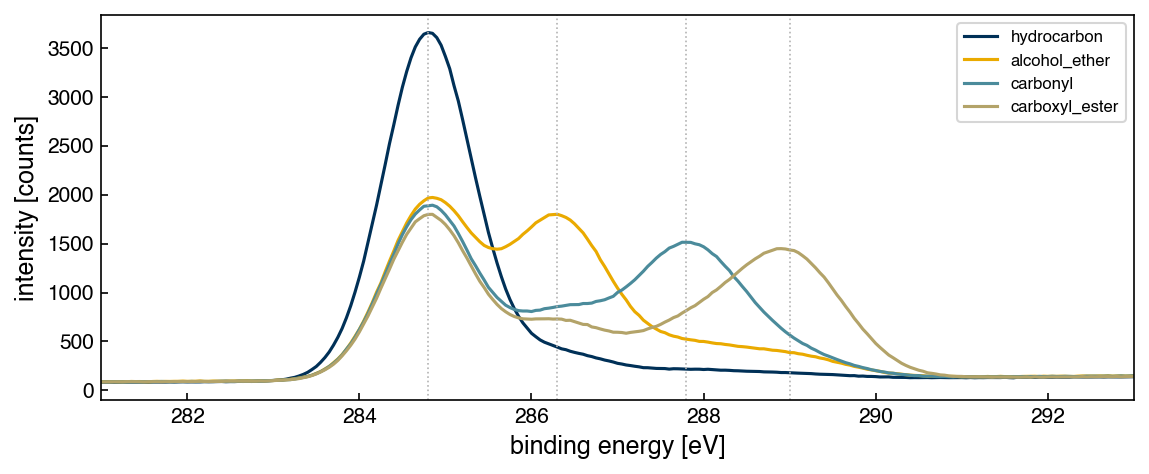

In [2]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for k, name in enumerate(['hydrocarbon', 'alcohol_ether', 'carbonyl', 'carboxyl_ester']):
    ax.plot(energy, raw[y_true == k].mean(axis=0), lw=1.5, label=name)
for e in (284.8, 286.3, 287.8, 289.0):
    ax.axvline(e, color='0.7', ls=':', lw=0.8)
ax.set_xlim(281, 293)
ax.set_xlabel('binding energy [eV]'); ax.set_ylabel('intensity [counts]')
ax.legend(fontsize=8);

Run this once to load the autograder. It will not run inside the book — use the
downloaded notebook.

In [ ]:
import otter
grader = otter.Notebook()

### Preprocessing — use exactly this

Raw XPS intensities carry an inelastic background and an arbitrary overall scale, so
spectra must be put on a common footing before any distance is computed. Use precisely
this recipe, or your numbers will not match:

1. **Background**: for each spectrum, linearly interpolate between the mean of the first
   20 channels and the mean of the last 20 channels; subtract it.
2. **Clip** any resulting negative values to zero.
3. **Normalize** each spectrum to unit area by dividing by `np.trapezoid(spectrum, energy)`.

In [ ]:
# YOUR CODE HERE — produce `X`, the (400, 301) preprocessed array used throughout
X = ...

---

## Part A — Skill Checks (30 pts)

Three questions, 10 points each.

A clustering has no canonical labeling — relabeling every cluster changes nothing about
the partition. So none of these questions ask *which* cluster a spectrum landed in. Each
asks for a quantity that is unchanged when clusters are renumbered, which is the only
kind of answer that can be checked automatically.

### A1. Cluster and score it without labels (10 pts)

:::{exercise}
:label: pr-eda-xps-silh

Run k-means on `X` with

```
KMeans(n_clusters=4, n_init=10, random_state=0)
```

and compute the **silhouette score** of the resulting partition using
`sklearn.metrics.silhouette_score`.

Silhouette needs no ground truth — it measures only how much tighter each cluster is
than its distance to the nearest other cluster.

Assign the score to `sil_k4`.
:::

In [ ]:
# YOUR CODE HERE
sil_k4 = ...

In [ ]:
grader.check("q1")

### A2. Score it against the truth (10 pts)

:::{exercise}
:label: pr-eda-xps-ari

Now use the labels. Compute the **adjusted Rand index** between `y_true` and your
k-means assignment with `sklearn.metrics.adjusted_rand_score`.

ARI compares two partitions by asking, over all pairs of points, how often the two
agree about whether the pair belongs together. Because it only ever looks at pairs, it
does not care what the clusters are named — which is exactly why it can be graded.

Assign it to `ari_k4`.
:::

In [ ]:
# YOUR CODE HERE
ari_k4 = ...

In [ ]:
grader.check("q2")

### A3. How many dimensions does the data really have? (10 pts)

:::{exercise}
:label: pr-eda-xps-pcadim

Fit `PCA(random_state=0)` to `X` and find the **smallest number of principal components
whose cumulative explained variance ratio reaches 0.95**.

Assign that integer to `n_pc_95`.
:::

In [ ]:
# YOUR CODE HERE
n_pc_95 = ...

In [ ]:
grader.check("q3")

---

## Part B — Visualization (35 pts)

:::{exercise}
:label: pr-eda-xps-kcurve

Two panels.

1. **Choosing k.** For `k = 2, 3, 4, 5, 6, 7, 8`, run the same k-means configuration and
   compute both the silhouette score and the ARI against `y_true`. Plot both against `k`
   on one set of axes (use a second y-axis if the scales make that clearer). Mark the `k`
   that maximizes silhouette.
2. **What the clusters actually are.** Project `X` onto its first two principal
   components and draw two scatter plots side by side: the same points colored first by
   k-means cluster, then by true `chemistry`.

Then, in **3–5 sentences**: silhouette picks the correct number of clusters, yet ARI at
that `k` is only about 0.39. Explain how both can be true at once, using what the PC1–PC2
scatter shows. Say what a silhouette score would have to look like for the clusters to
correspond to genuinely distinct chemistries.

Label all axes with units.
:::

In [ ]:
# YOUR CODE HERE
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

---

## Part C — Open Ended (35 pts)

:::{exercise}
:label: pr-eda-xps-continuum

k-means found the right number of clusters and still failed to recover the chemistry.
Work out why, and say what — if anything — would do better.

Your answer should include:

1. At least **three** clustering algorithms from {doc}`Clustering </5-exploratory_data_analysis/Topic5.3-Clustering>` besides
   k-means — a Gaussian mixture, an agglomerative method, and a density-based method are
   the obvious choices — each scored by ARI against `y_true`.
2. An explanation of the result from A3: four chemical components, three principal
   components. What constraint links them, and what shape does that force the data into?
3. A short written argument (**one paragraph**) about whether *any* clustering algorithm
   should be expected to recover these four chemistries, citing your own numbers.

One of the algorithms will fail dramatically — labeling most of the dataset as noise or
finding no clusters at all. Do not treat that as a bug to be tuned away. Explain what its
failure tells you about the shape of the data.

There is more than one defensible conclusion. You are graded on the reasoning and the
evidence.
:::

In [ ]:
# YOUR CODE HERE

---

## Summary

- Part A scored a clustering two ways — silhouette, which needs no labels, and the
  adjusted Rand index, which uses them. Both are invariant to how clusters are numbered,
  which is what makes an unsupervised result checkable at all.
- Part B showed silhouette selecting the correct k while ARI stayed near 0.39, and the
  PC1–PC2 projection revealed the reason: one connected cloud, not four islands.
- Part C traced that back to the closure constraint on compositional data, and used a
  density-based method's failure as positive evidence about the shape of the dataset.

## Additional Reading

1. NIST X-ray Photoelectron Spectroscopy Database, [SRD 20 Version 5.0](https://srdata.nist.gov/xps/)
   — the source of the C 1s chemical shifts used to build this dataset.
2. [`sklearn.metrics.adjusted_rand_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)
   — and the surrounding discussion of why unadjusted agreement measures are misleading.
3. J. Aitchison, *The Statistical Analysis of Compositional Data*, J. R. Stat. Soc. B
   **44**, 139–177 (1982) — the origin of the simplex view of closed data.